In [98]:
import sys
sys.path.append('..')

In [99]:
import numpy as np 
import seaborn as sns

import matplotlib.pyplot as plt 
import matplotlib.ticker as ticker
from matplotlib.ticker import FormatStrFormatter

import pickle

In [100]:
# sns.set(style="white", palette="muted", color_codes=True)
from matplotlib.offsetbox import AnchoredText
from matplotlib.ticker import FuncFormatter, StrMethodFormatter

%matplotlib inline

# import mpld3
# mpld3.enable_notebook()
np.set_printoptions(precision=2, suppress=True)

In [101]:
nice_fonts = {
        # Use LaTeX to write all text
        "text.usetex": True,
        "font.family": "serif",
        # Use 10pt font in plots, to match 10pt font in document
        "axes.labelsize": 10,
        "font.size": 10,
        # Make the legend/label fonts a little smaller
        "legend.fontsize": 8,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
}

In [102]:
pct_formatter = StrMethodFormatter('{x:.1f}')

# There are five preset seaborn themes: darkgrid, whitegrid, dark, white, and ticks
sns.set_style("white")
# sns.set() 
# blue, green, *_ = sns.color_palette()

 
plt.rc('figure', figsize=(12, 8))

LABELSIZE = 14
plt.rc('axes', labelsize=LABELSIZE)
plt.rc('axes', titlesize=LABELSIZE)
plt.rc('figure', titlesize=LABELSIZE)
plt.rc('legend', fontsize=LABELSIZE)
plt.rc('xtick', labelsize=LABELSIZE)
plt.rc('ytick', labelsize=LABELSIZE)
plt.rc('axes', labelpad=18)
plt.rcParams["axes.formatter.useoffset"] = False 
# plt.rcParams["axes.StrMethodFormatter"] = pct_formatter 

# use LaTeX fonts in the plot
plt.rc('text', usetex=True)
# plt.rc('font', family='serif')
# plt.rc('font',**{'family':'sans-serif','sans-serif':['Palatino']})
# plt.rcParams.keys()


plt.rcParams.update(nice_fonts)

In [103]:
def set_size(width, fraction=1):
    """ Set aesthetic figure dimensions to avoid scaling in latex.

    Parameters
    ----------
    width: float
            Width in pts
    fraction: float
            Fraction of the width which you wish the figure to occupy

    Returns
    -------
    fig_dim: tuple
            Dimensions of figure in inches
    """
    # Width of figure
    fig_width_pt = width * fraction

    # Convert from pt to inches
    inches_per_pt = 1 / 72.27

    # Golden ratio to set aesthetic figure height
    golden_ratio = (5**.5 - 1) / 2

    # Figure width in inches
    fig_width_in = fig_width_pt * inches_per_pt
    # Figure height in inches
    fig_height_in = fig_width_in * golden_ratio

    fig_dim = (fig_width_in, fig_height_in)

    return fig_dim


Figure codes are from 
https://jwalton.info/Embed-Publication-Matplotlib-Latex/

### LOAD PICKLE FILE

In [104]:
file_name_noobs = '../Logs/logs_pickle_tire_no_obstacle.pickle'
file_name_obs = '../Logs/logs_pickle_tire_obstacle.pickle'

In [105]:
with open(file_name_obs, 'rb') as handle:
    histories_obs = pickle.load(handle)

with open(file_name_noobs, 'rb') as handle:
    histories_noobs = pickle.load(handle)    

In [106]:
state_history_noobs = histories_noobs['States']
control_history_noobs = histories_noobs['Controls']
optimization_history_noobs = histories_noobs['Optimization_Params']
current_map_noobs = histories_noobs['Current_Map']
kappa_noobs = histories_noobs['kappa']
# obs_loc = np.array(histories_noobs['obstacle_locs'])

In [107]:
state_history_obs = histories_obs['States']
control_history_obs = histories_obs['Controls']
optimization_history_obs = histories_obs['Optimization_Params']
current_map_obs = histories_obs['Current_Map']
kappa = histories_obs['kappa']
obs_loc = np.array(histories_obs['obstacle_locs'])

In [108]:
obs_loc.shape

(2, 2)

In [109]:
pathname = "../test_path.txt"
rpath = np.loadtxt(pathname)

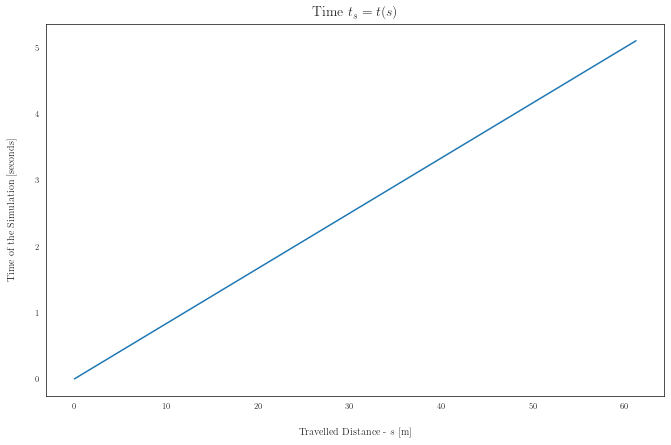

In [110]:
width = 800
fig,ax = plt.subplots(figsize=set_size(width, fraction=1))

states = state_history_noobs    
ax.plot(states[3, :], states[8, :],  label=f'last iteration')
ax.set_title(r'Time $t_s = t(s)$')
ax.set_xlabel(r'Travelled Distance - $s$ [m]')
ax.set_ylabel(r'Time of the Simulation [seconds]')
# ax.grid()

# Save and remove excess whitespace
fig_path = '../Figures/'
fig_name = 's_vs_t.pdf'
plt.savefig(fig_path+fig_name, format='pdf', bbox_inches='tight')

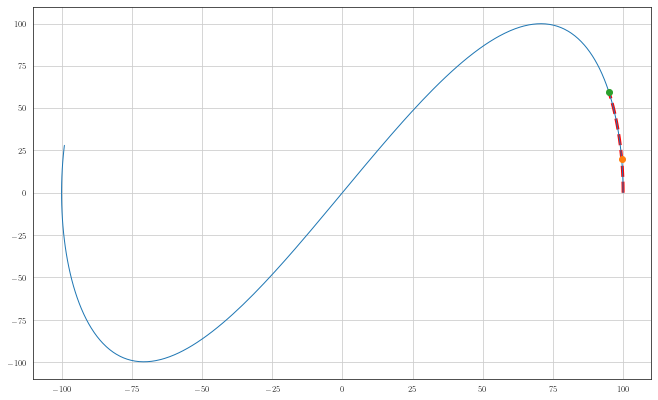

In [111]:
width = 800
fig,ax = plt.subplots(figsize=set_size(width, fraction=1))

states = state_history_noobs    
ax.plot(states[0, :], states[1, :], '--r', linewidth=3,  label='Vehicle Path')
ax.plot(rpath[:1000, 1], rpath[:1000, 2], linewidth=1, label='Tracked Path')
ax.grid() 

for i in range(obs_loc.shape[0]):
    ax.plot(obs_loc[i, 0], obs_loc[i, 1], marker='o')

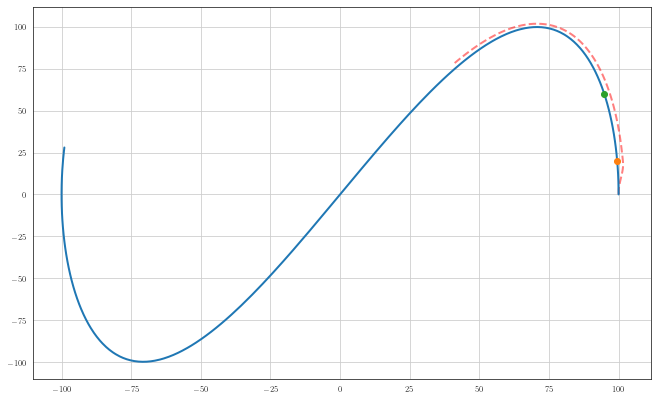

In [112]:
width = 800
fig,ax = plt.subplots(figsize=set_size(width, fraction=1))

states = state_history_obs    
ax.plot(states[0, :], states[1, :], '--r', linewidth=2,  alpha= 0.5, label='Vehicle Path')
ax.plot(rpath[:1000, 1], rpath[:1000, 2], linewidth=2, label='Tracked Path')
ax.grid() 

for i in range(obs_loc.shape[0]):
    ax.plot(obs_loc[i, 0], obs_loc[i, 1], marker='o')

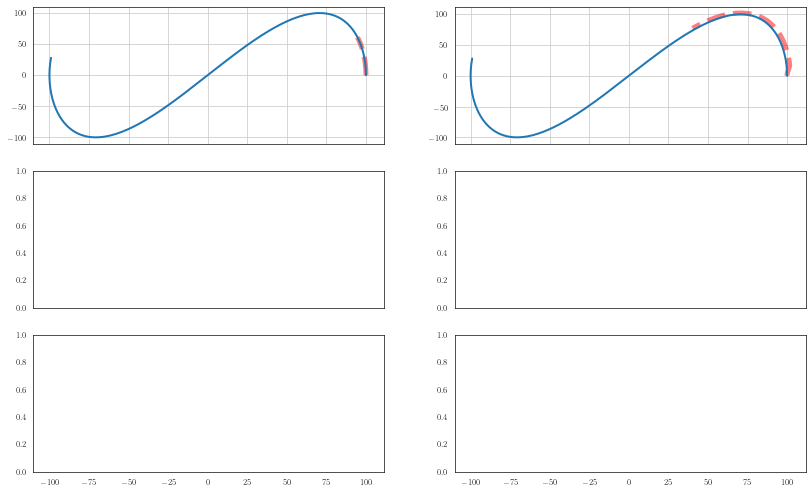

In [113]:
width = 1000
fig,axes = plt.subplots(nrows=3, ncols=2, sharex='all', figsize=set_size(width, fraction=1))

states_noobs = state_history_noobs  
states_obs = state_history_obs  

## Trajectory
axes[0, 0].plot(states_noobs[0, :], states_noobs[1, :], '--r', linewidth=5,  alpha= 0.5, label='Vehicle Path')
axes[0, 0].plot(rpath[:1000, 1], rpath[:1000, 2], linewidth=2, label='Tracked Path')
axes[0, 0].grid() 

axes[0, 1].plot(state_history_obs[0, :], state_history_obs[1, :], '--r', linewidth=5,  alpha= 0.5, label='Vehicle Path')
axes[0, 1].plot(rpath[:1000, 1], rpath[:1000, 2], linewidth=2, label='Tracked Path')
axes[0, 1].grid() 



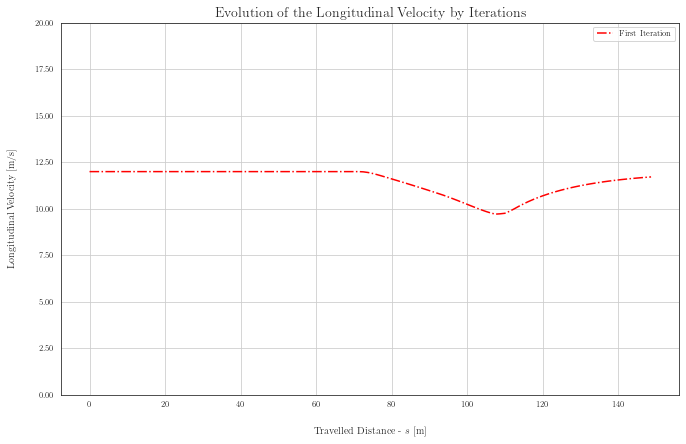

In [114]:
width = 800
fig,ax = plt.subplots(figsize=set_size(width, fraction=1))

states = state_history_obs    
ax.plot(states[3, :], states[6, :], '-.r', label=f'First Iteration')

ax.set_title('Evolution of the Longitudinal Velocity by Iterations')
ax.set_xlabel(r'Travelled Distance - $s$ [m]')
ax.set_ylabel('Longitudinal Velocity [m/s]')
ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
plt.legend(loc='best')

# ax.grid(axis='y',  linestyle='--')
ax.grid()

ax.set_ylim([0, 20])

# Save and remove excess whitespace
fig_path = '../Figures/'
fig_name = 'Vx.pdf'
plt.savefig(fig_path+fig_name, format='pdf', bbox_inches='tight', alpha=0)

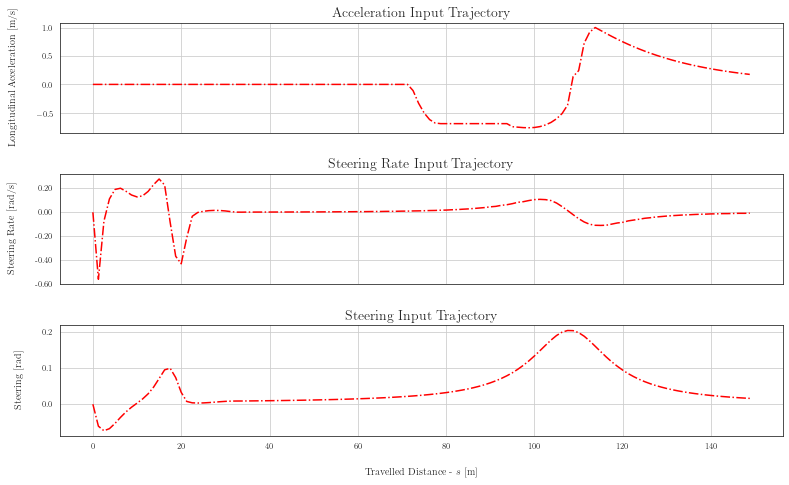

In [115]:
width = 800
fig,axes = plt.subplots(nrows=3, ncols=1, sharex='all', figsize=set_size(width, fraction=1))

controls = control_history_obs 
states = state_history_obs

axes[0].plot(states[3, :], controls[0, :], '-.r', label=f'Longitudinal Acceleration')
axes[1].plot(states[3, :], controls[1, :], '-.r', label=f'Steering Rate Input')
axes[2].plot(states[3, :], states[7, :], '-.r', label=f'Steering Angle')

    
axes[0].set_title('Acceleration Input Trajectory')
# axes[0].set_xlabel('Number of Time Steps')
axes[0].set_ylabel('Longitudinal Acceleration [m/s]')
# axes[0].legend(bbox_to_anchor=(1, 1))
axes[0].grid()

# axes[0].set_ylim([-10, 10])

axes[1].set_title('Steering Rate Input Trajectory')
# axes[1].set_xlabel('Number of Time Steps')
axes[1].set_ylabel('Steering Rate [rad/s]')
axes[1].yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
axes[1].grid()

axes[2].set_title('Steering Input Trajectory')
axes[2].set_xlabel(r'Travelled Distance - $s$ [m]')
axes[2].set_ylabel('Steering [rad]')
axes[2].grid()
plt.tight_layout()


# Save and remove excess whitespace
fig_path = '../Figures/'
fig_name = 'inputs.pdf'
plt.savefig(fig_path+fig_name, format='pdf', bbox_inches='tight', alpha=0)

### ERROR PLOTS

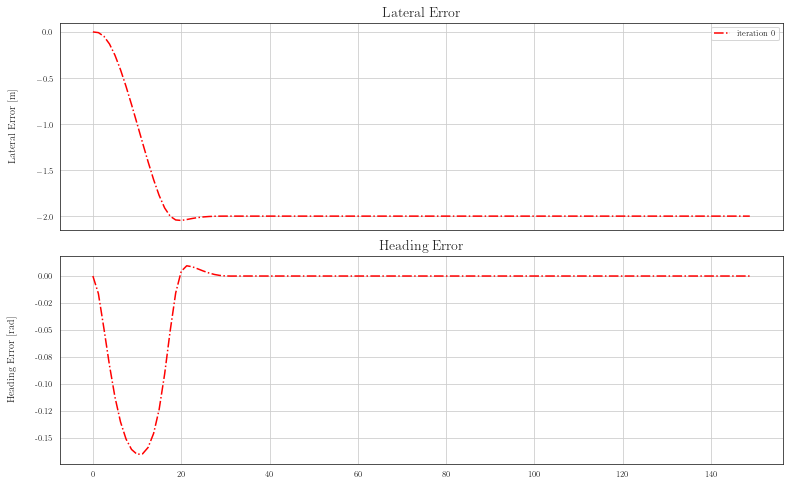

In [116]:
width = 800
fig,axes = plt.subplots(nrows=2, ncols=1, sharex='all', figsize=set_size(width, fraction=1))

controls = control_history_obs 
states = state_history_obs 

axes[0].plot(states[3, :], states[4, :], '-.r', label=f'iteration {0}')
axes[1].plot(states[3, :], states[5, :], '-.r', label=f'iteration {0}')
 

    
axes[0].set_title('Lateral Error')
# axes[0].set_xlabel('Number of Time Steps')
axes[0].set_ylabel('Lateral Error [m]')
axes[0].legend(bbox_to_anchor=(1, 1))
axes[0].grid()

# axes[0].set_ylim([-10, 10])

axes[1].set_title('Heading Error')
axes[1].set_ylabel('Heading Error [rad]')
axes[1].yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
axes[1].grid()
 

plt.tight_layout()


# Save and remove excess whitespace
# fig_path = '../Figures/'
# fig_name = 'inputs.pdf'
# plt.savefig(fig_path+fig_name, format='pdf', bbox_inches='tight', alpha=0)

### Friction Circle Constraint Satisfaction

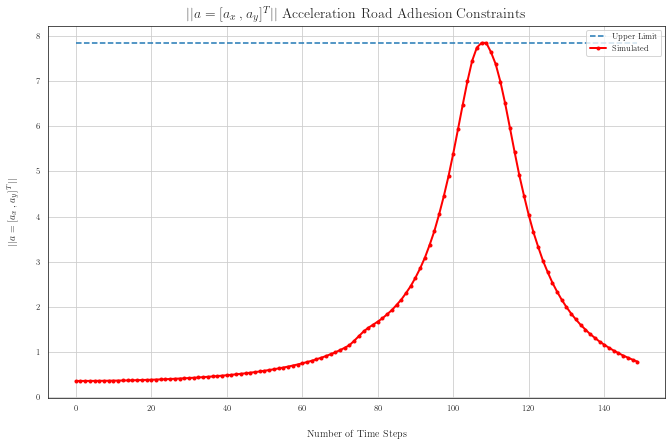

In [117]:
controls = control_history_obs 
states = state_history_obs 

muge0 = 0.8 * 9.81

width = 800
fig,ax = plt.subplots(nrows=1, ncols=1, sharex='all', figsize=set_size(width, fraction=1))


ax.plot(states[3, :], [muge0]*states.shape[1], '--', label='Upper Limit')
ax.plot(states[3, :], np.hypot(kappa.flatten()*states[6, :]**2, controls[0, :]), '.-r', linewidth=2.0, label=f'Simulated')   


ax.set_title(r'$||a=[a_x\:, a_y]^T||$' + ' Acceleration Road Adhesion Constraints')
ax.set_xlabel('Number of Time Steps')
ax.set_ylabel(r'$||a=[a_x\:, a_y]^T||$')
ax.grid()

plt.legend(loc='upper right')

In [118]:
states.shape

(9, 120)

In [119]:
ax.plot(states[3, :], np.hypot(kappa.flatten()*states[6, :]**2, controls[0, :]), '.-r', linewidth=2.0, label=f'iteration 0')   

In [120]:
np.hypot(kappa*states[6, :]**2, controls[0, :]).shape

(1, 120)

In [121]:
states[3, :].shape

(120,)